In [ ]:
# 1. Kết nối với Drive
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)


Mounted at /content/gdrive


In [ ]:
# 1. CÀI ĐẶT MÔI TRƯỜNG VÀ THƯ VIỆN (Chỉ chạy 1 lần)
# Thêm -qq và -q để ẩn bớt log cài đặt cho gọn màn hình
!apt-get install openjdk-11-jdk-headless -qq -y
!pip install pyspark==3.5.0 findspark notebook plotly pandas matplotlib graphviz -q

# Ghi nhận Jupyter kernel
!python -m ipykernel install --user --name pyspark-env --display-name "Python (PySpark)"

# 2. IMPORT THƯ VIỆN & THIẾT LẬP BIẾN MÔI TRƯỜNG
import os
import sys
import findspark
import pyspark
import pandas as pd
import matplotlib

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/usr/local/lib/python3.12/dist-packages/pyspark"

# Khởi tạo findspark
findspark.init()

# 3. KIỂM TRA VÀ IN VERSION (Theo yêu cầu)
print("="*30)
print("THÔNG TIN MÔI TRƯỜNG & PHIÊN BẢN")
print("="*30)
print(f"Python version: {sys.version.split(' ')[0]}")
!java -version
print(f"PySpark version: {pyspark.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"JAVA_HOME = {os.environ.get('JAVA_HOME')}")
print(f"SPARK_HOME = {os.environ.get('SPARK_HOME')}")
print("="*30)

# 4. KHỞI TẠO SPARK SESSION & TEST
from pyspark.sql import SparkSession

# Gộp cấu hình offHeap vào SparkSession chính thức
spark = SparkSession.builder \
    .appName("Olist_Machine_Learning") \
    .config("spark.memory.offHeap.enabled", "true") \
    .config("spark.memory.offHeap.size", "10g") \
    .getOrCreate()

print("\nĐã khởi tạo SparkSession thành công!")

# Chạy test DataFrame để đảm bảo Spark đang hoạt động tốt
df = spark.createDataFrame([(1, "hello"), (2, "world")], ["id", "text"])
df.show()

Selecting previously unselected package openjdk-11-jre-headless:amd64.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../openjdk-11-jre-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Selecting previously unselected package openjdk-11-jdk-headless:amd64.
Preparing to unpack .../openjdk-11-jdk-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jdk-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Setting up openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/jjs to provide /usr/bin/jjs (jjs) in auto mode
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/rmid to provide /usr/bin/rmid (rmid) in auto mode
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/pack200 to provide /usr/bin/pack200 (pack200) in auto mode
update-alternatives: using /usr/lib/jvm/jav

In [ ]:
data_path = "/content/gdrive/MyDrive/BIGDATA/Dataset cuối kỳ/Dataset cuối kỳ/cleaned_master_data.parquet"

# Lúc này biến 'spark' đã tồn tại nên sẽ không bị lỗi nữa
df_master = spark.read.parquet(data_path)

# Kiểm tra xem dữ liệu đã lên chưa
df_master.show(5)

+--------------------+---------------------+--------------------+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+--------------------+------------------------+--------------------+--------------+-------------+-------------------+-----+-------------+------------------+------------+--------------------+-------------+--------------------+------------+--------------------+----------------------+--------------------+-----------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+-----------------------------+----------------------+-------------------+------------+---------------------------+-------------------+-------------------+--------------------+-----------------+
|           seller_id|product_category_name|          product_id|            order_id|    

In [ ]:
import pyspark.sql.functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

print("1. Đang lấy ngày tham chiếu lớn nhất trong df_master...")
# Lấy ngày giao dịch gần nhất làm mốc thời gian để tính Recency
ref_date = df_master.agg(F.max("order_purchase_timestamp")).collect()[0][0]
print(f"Ngày tham chiếu (Reference Date) là: {ref_date}")

print("\n2. Đang tính toán RFM gốc...")
# Tính Recency, Frequency, Monetary
df_rfm = (df_master
    .groupBy("customer_unique_id")
    .agg(
        F.datediff(F.lit(ref_date), F.max("order_purchase_timestamp")).alias("Recency"),
        F.countDistinct("order_id").alias("Frequency"),
        F.round(F.sum("payment_value"), 2).alias("Monetary")
    )
    .dropna(subset=["Recency", "Frequency", "Monetary"]) # Loại bỏ các khách hàng bị thiếu dữ liệu
)

print("\n3. Đang thực hiện Feature Engineering (Log Transform & Scaling)...")
# Biến đổi Logarit để kéo phân phối của R, F, M bớt lệch (skewed)
df_rfm_log = (df_rfm
    .withColumn("Log_R", F.log1p(F.col("Recency")))
    .withColumn("Log_F", F.log1p(F.col("Frequency")))
    .withColumn("Log_M", F.log1p(F.col("Monetary")))
)

# Gom 3 cột Log thành Vector
rfm_assembler = VectorAssembler(
    inputCols=["Log_R", "Log_F", "Log_M"],
    outputCol="unscaled_features"
)

# Chuẩn hóa StandardScaler để khoảng cách Euclidean không bị chi phối bởi biến nào
rfm_scaler = StandardScaler(
    inputCol="unscaled_features",
    outputCol="features",
    withStd=True,
    withMean=True
)

# Đóng gói và chạy Pipeline
rfm_pipeline = Pipeline(stages=[rfm_assembler, rfm_scaler])
rfm_model = rfm_pipeline.fit(df_rfm_log)
df_rfm_final = rfm_model.transform(df_rfm_log)

print("\n✅ Hoàn tất Bước 1! Bảng dữ liệu cuối cùng sẵn sàng cho Clustering:")
df_rfm_final.select("customer_unique_id", "Recency", "Frequency", "Monetary", "features").show(5, truncate=False)
# Lệnh summary() sẽ hiển thị đầy đủ count, mean, std, min, 25%, 50%, 75%, max
df_rfm.select("Recency", "Frequency", "Monetary").summary().show()

1. Đang lấy ngày tham chiếu lớn nhất trong df_master...
Ngày tham chiếu (Reference Date) là: 2018-08-29 15:00:37

2. Đang tính toán RFM gốc...

3. Đang thực hiện Feature Engineering (Log Transform & Scaling)...

✅ Hoàn tất Bước 1! Bảng dữ liệu cuối cùng sẵn sàng cho Clustering:
+--------------------------------+-------+---------+--------+--------------------------------------------------------------+
|customer_unique_id              |Recency|Frequency|Monetary|features                                                      |
+--------------------------------+-------+---------+--------+--------------------------------------------------------------+
|f8d62e8ff724bf75c20ffd5faf7b9e30|87     |1        |164.58  |[-0.7317208560755197,-0.15823202134648282,0.3290885178311296] |
|e533c359f12f908382cf31d51ef1e684|70     |1        |43.45   |[-0.9599890396186257,-0.15823202134648282,-1.1208693691495966]|
|10a019fa89b5f15af81109bbbd7b02f3|232    |1        |106.87  |[0.3037225221884252,-0.158232021346

In [ ]:
# Xuất 5000 khách hàng để bảng kết quả nhìn "xịn" hơn
df_rfm_final.select("customer_unique_id", "Recency", "Frequency", "Monetary", "Log_R", "Log_F", "Log_M") \
    .limit(5000) \
    .toPandas() \
    .to_csv("data_test_5000.csv", index=False)

# KMEANS

Đang chạy vòng lặp tìm K tối ưu cho K-Means (từ 2 đến 10)... Quá trình này có thể mất vài phút.
Hoàn thành K = 2 | WSSSE = 192,734 | Silhouette Score = 0.9100
Hoàn thành K = 3 | WSSSE = 137,209 | Silhouette Score = 0.4502
Hoàn thành K = 4 | WSSSE = 133,817 | Silhouette Score = 0.4528
Hoàn thành K = 5 | WSSSE = 80,534 | Silhouette Score = 0.5753
Hoàn thành K = 6 | WSSSE = 58,354 | Silhouette Score = 0.5066
Hoàn thành K = 7 | WSSSE = 55,044 | Silhouette Score = 0.5079
Hoàn thành K = 8 | WSSSE = 46,900 | Silhouette Score = 0.4783
Hoàn thành K = 9 | WSSSE = 42,175 | Silhouette Score = 0.4860
Hoàn thành K = 10 | WSSSE = 37,358 | Silhouette Score = 0.4900


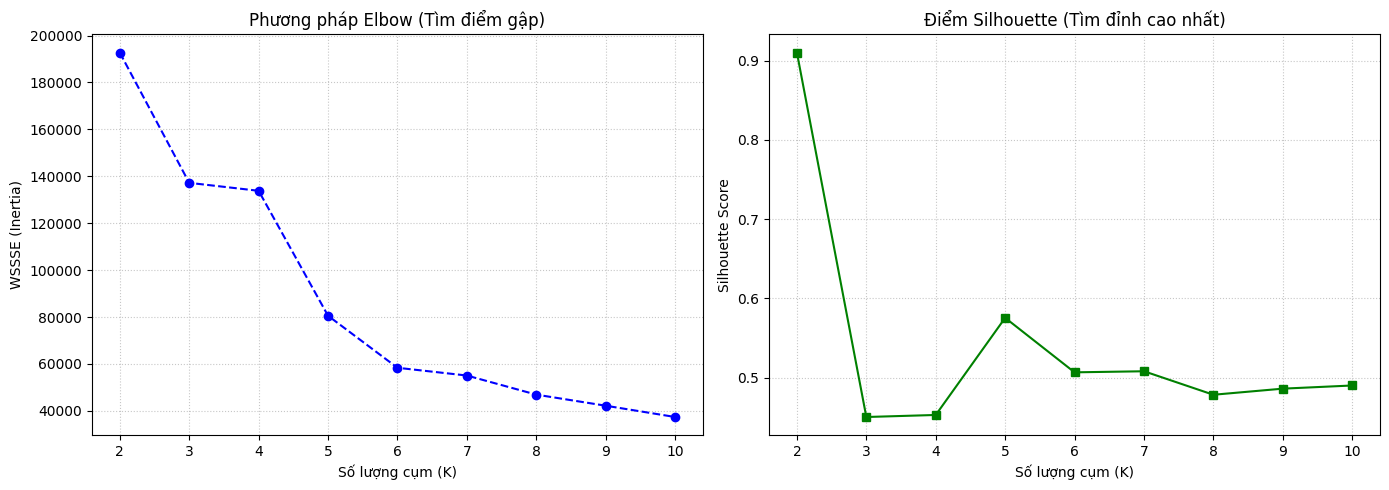

In [ ]:
import matplotlib.pyplot as plt
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# Khởi tạo danh sách lưu kết quả
k_values = list(range(2, 11))
wssse_scores = []
silhouette_scores = []

# Khởi tạo công cụ đánh giá Silhouette
evaluator = ClusteringEvaluator(
    predictionCol="prediction",
    featuresCol="features",
    metricName="silhouette"
)

print("Đang chạy vòng lặp tìm K tối ưu cho K-Means (từ 2 đến 10)... Quá trình này có thể mất vài phút.")

for k in k_values:
    # 1. Khai báo mô hình K-Means với các siêu tham số yêu cầu
    kmeans = KMeans(featuresCol="features", k=k, seed=42, initMode="k-means||", initSteps=2, tol=1e-4)
    model = kmeans.fit(df_rfm_final)

    # 2. Lấy chỉ số WSSSE (Cost) cho biểu đồ Elbow
    wssse = model.summary.trainingCost
    wssse_scores.append(wssse)

    # 3. Dự đoán để tính Silhouette Score
    predictions = model.transform(df_rfm_final)
    silhouette = evaluator.evaluate(predictions)
    silhouette_scores.append(silhouette)

    print(f"Hoàn thành K = {k} | WSSSE = {wssse:,.0f} | Silhouette Score = {silhouette:.4f}")

# ==========================================
# VẼ BIỂU ĐỒ ELBOW VÀ SILHOUETTE ĐỂ TÌM K
# ==========================================
plt.figure(figsize=(14, 5))

# Biểu đồ 1: Phương pháp Elbow (WSSSE)
plt.subplot(1, 2, 1)
plt.plot(k_values, wssse_scores, marker='o', linestyle='--', color='b')
plt.title('Phương pháp Elbow (Tìm điểm gập)')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('WSSSE (Inertia)')
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.7)

# Biểu đồ 2: Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='s', linestyle='-', color='g')
plt.title('Điểm Silhouette (Tìm đỉnh cao nhất)')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
from pyspark.ml.clustering import KMeans
import pyspark.sql.functions as F

print("1. Đang huấn luyện K-Means với K = 4...")
# Khai báo mô hình K-Means
kmeans_optimal = KMeans(featuresCol="features", k=4, seed=42, initMode="k-means||", initSteps=2, tol=1e-4)
kmeans_model = kmeans_optimal.fit(df_rfm_final)

print("2. Đang phân cụm khách hàng...")
# Gán nhãn cụm cho tập dữ liệu
df_kmeans_result = kmeans_model.transform(df_rfm_final)

# Đổi tên cột prediction cho rõ ràng
df_kmeans_result = df_kmeans_result.withColumnRenamed("prediction", "Cluster_KMeans")

# Lưu lại các chỉ số đánh giá để điền vào Bảng Báo Cáo
wssse_final = kmeans_model.summary.trainingCost
evaluator = ClusteringEvaluator(predictionCol="Cluster_KMeans", featuresCol="features", metricName="silhouette")
silhouette_final = evaluator.evaluate(df_kmeans_result)

print(f"\n[KẾT QUẢ MÔ HÌNH K-MEANS]")
print(f"- K tối ưu: 4")
print(f"- Silhouette Score: {silhouette_final:.4f}")
print(f"- Within-Set SSE: {wssse_final:,.0f}")

# ==========================================================
# 3. THỐNG KÊ ĐẶC ĐIỂM CỦA TỪNG CỤM (PROFILING)
# ==========================================================
print("\n--- ĐẶC ĐIỂM CÁC CỤM KHÁCH HÀNG (K-MEANS) ---")
# Tính giá trị trung bình của R, F, M gốc (chưa log) để dễ diễn giải Business
cluster_profiling = (df_kmeans_result
    .groupBy("Cluster_KMeans")
    .agg(
        F.count("customer_unique_id").alias("Số_Lượng_KH"),
        F.round(F.mean("Recency"), 1).alias("Trung_bình_Recency"),
        F.round(F.mean("Frequency"), 2).alias("Trung_bình_Frequency"),
        F.round(F.mean("Monetary"), 2).alias("Trung_bình_Monetary")
    )
    .orderBy("Cluster_KMeans")
)

cluster_profiling.show()

1. Đang huấn luyện K-Means với K = 4...
2. Đang phân cụm khách hàng...

[KẾT QUẢ MÔ HÌNH K-MEANS]
- K tối ưu: 4
- Silhouette Score: 0.4528
- Within-Set SSE: 133,817

--- ĐẶC ĐIỂM CÁC CỤM KHÁCH HÀNG (K-MEANS) ---
+--------------+-----------+------------------+--------------------+-------------------+
|Cluster_KMeans|Số_Lượng_KH|Trung_bình_Recency|Trung_bình_Frequency|Trung_bình_Monetary|
+--------------+-----------+------------------+--------------------+-------------------+
|             0|      55772|             222.2|                 1.0|               76.0|
|             1|         43|             150.4|                4.95|            1574.53|
|             2|      36202|             265.4|                 1.0|             403.67|
|             3|       2417|             208.6|                2.06|             444.66|
+--------------+-----------+------------------+--------------------+-------------------+



1. Đang lấy mẫu (sample) 15% dữ liệu K-Means để vẽ biểu đồ...
2. Đang vẽ biểu đồ RFM Pairs cho K-Means...


<Figure size 1200x1000 with 0 Axes>

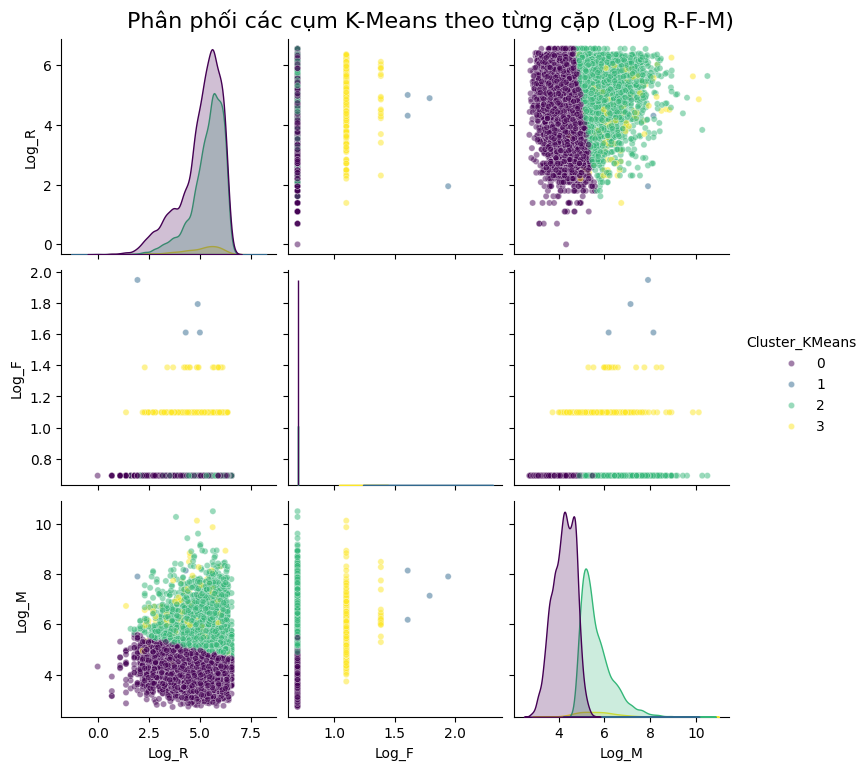

3. Đang vẽ biểu đồ 2D PCA Projection cho K-Means...


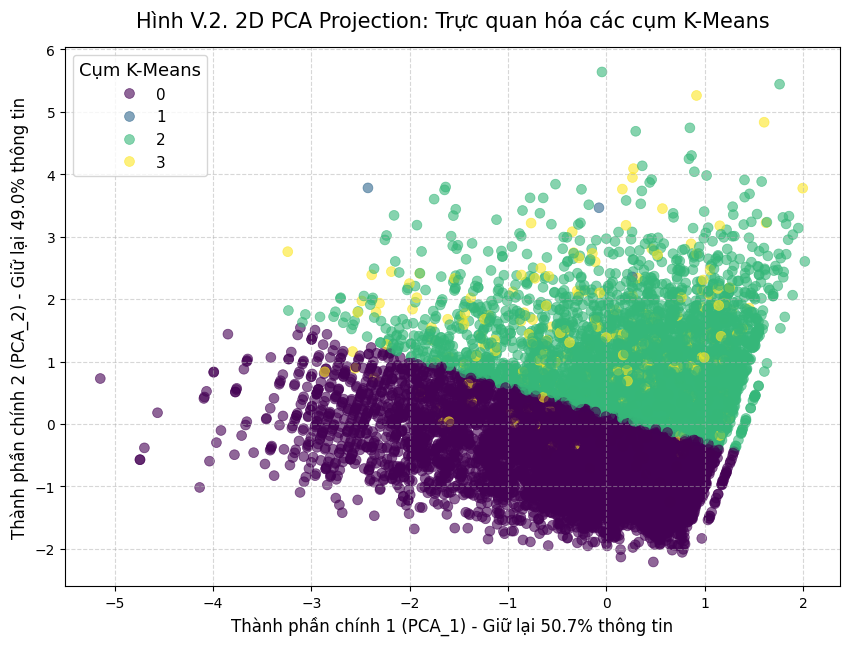

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

print("1. Đang lấy mẫu (sample) 15% dữ liệu K-Means để vẽ biểu đồ...")
# CHỈNH SỬA: Đổi df_bkm_result thành df_kmeans_result
df_plot_spark = df_kmeans_result.sample(fraction=0.15, seed=42)

# CHỈNH SỬA: Chọn cột Cluster_KMeans thay vì Cluster_BKM
df_plot = df_plot_spark.select("Recency", "Frequency", "Monetary", "Cluster_KMeans").toPandas()

# ==========================================================
# 📈 BIỂU ĐỒ 1: RFM PAIRS (Phân phối chéo giữa R, F, M)
# ==========================================================
print("2. Đang vẽ biểu đồ RFM Pairs cho K-Means...")
df_plot['Log_R'] = np.log1p(df_plot['Recency'])
df_plot['Log_F'] = np.log1p(df_plot['Frequency'])
df_plot['Log_M'] = np.log1p(df_plot['Monetary'])

plt.figure(figsize=(12, 10))
# CHỈNH SỬA: hue="Cluster_KMeans"
pair_plot = sns.pairplot(
    df_plot,
    vars=["Log_R", "Log_F", "Log_M"],
    hue="Cluster_KMeans",
    palette="viridis", # Đổi màu viridis cho hiện đại hoặc giữ Set1 tùy bạn
    diag_kind="kde",
    plot_kws={'alpha': 0.5, 's': 20}
)
pair_plot.fig.suptitle("Phân phối các cụm K-Means theo từng cặp (Log R-F-M)", y=1.02, fontsize=16)
plt.show()

# ==========================================================
# 📉 BIỂU ĐỒ 2: 2D PCA PROJECTION (Trực quan hóa K-Means)
# ==========================================================
print("3. Đang vẽ biểu đồ 2D PCA Projection cho K-Means...")
pca = PCA(n_components=2)
pca_features = pca.fit_transform(df_plot[['Log_R', 'Log_F', 'Log_M']])

df_plot['PCA_1'] = pca_features[:, 0]
df_plot['PCA_2'] = pca_features[:, 1]
var_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_plot,
    x='PCA_1',
    y='PCA_2',
    hue='Cluster_KMeans', # CHỈNH SỬA: hue="Cluster_KMeans"
    palette='viridis',
    alpha=0.6,
    s=50,
    edgecolor=None
)

plt.title("Hình V.2. 2D PCA Projection: Trực quan hóa các cụm K-Means", fontsize=15, pad=15)
plt.xlabel(f"Thành phần chính 1 (PCA_1) - Giữ lại {var_ratio[0]*100:.1f}% thông tin", fontsize=12)
plt.ylabel(f"Thành phần chính 2 (PCA_2) - Giữ lại {var_ratio[1]*100:.1f}% thông tin", fontsize=12)
plt.legend(title="Cụm K-Means", title_fontsize='13', fontsize='11', loc='best')
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# B KMS

⏳ Đang chạy vòng lặp tìm K cho Bisecting K-Means (2-10)...
K = 2 | WSSSE = 217,399 | Silhouette = 0.5733
K = 3 | WSSSE = 175,410 | Silhouette = 0.3911
K = 4 | WSSSE = 89,462 | Silhouette = 0.5300
K = 5 | WSSSE = 80,751 | Silhouette = 0.3892
K = 6 | WSSSE = 70,722 | Silhouette = 0.3948
K = 7 | WSSSE = 56,499 | Silhouette = 0.4396
K = 8 | WSSSE = 51,687 | Silhouette = 0.4409
K = 9 | WSSSE = 47,664 | Silhouette = 0.3941
K = 10 | WSSSE = 43,719 | Silhouette = 0.3883


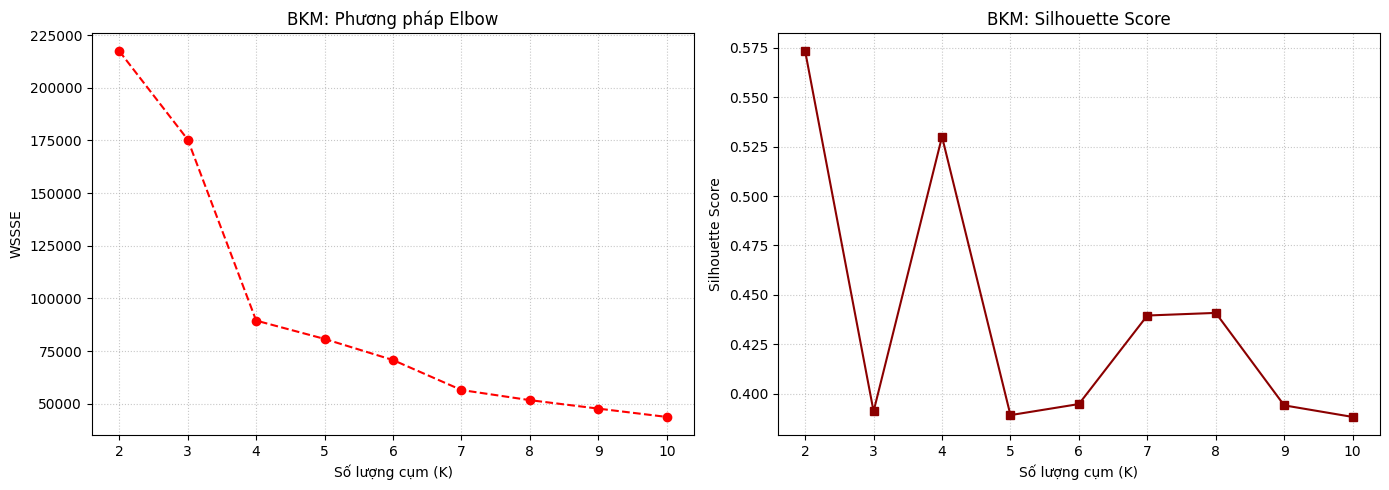

In [ ]:
from pyspark.ml.clustering import BisectingKMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt

# 1. Khởi tạo danh sách lưu kết quả
k_values = list(range(2, 11))
bkm_wssse_scores = []
bkm_silhouette_scores = []

# Khởi tạo công cụ đánh giá Silhouette
evaluator = ClusteringEvaluator(
    predictionCol="prediction",
    featuresCol="features",
    metricName="silhouette"
)

print("⏳ Đang chạy vòng lặp tìm K cho Bisecting K-Means (2-10)...")

for k in k_values:
    # 2. Khai báo mô hình Bisecting K-Means
    # Thêm tham số minDivisibleClusterSize theo yêu cầu (mặc định thường là 1.0)
    bkm = BisectingKMeans(
        featuresCol="features",
        k=k,
        seed=42,
        minDivisibleClusterSize=1.0
    )

    model = bkm.fit(df_rfm_final)

    # 3. Lấy WSSSE (Cost)
    wssse = model.summary.trainingCost
    bkm_wssse_scores.append(wssse)

    # 4. Tính Silhouette Score
    predictions = model.transform(df_rfm_final)
    silhouette = evaluator.evaluate(predictions)
    bkm_silhouette_scores.append(silhouette)

    print(f"K = {k} | WSSSE = {wssse:,.0f} | Silhouette = {silhouette:.4f}")

# ==========================================
# VẼ BIỂU ĐỒ ELBOW VÀ SILHOUETTE CHO BKM
# ==========================================
plt.figure(figsize=(14, 5))

# Biểu đồ 1: Elbow cho BKM
plt.subplot(1, 2, 1)
plt.plot(k_values, bkm_wssse_scores, marker='o', linestyle='--', color='red')
plt.title('BKM: Phương pháp Elbow')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('WSSSE')
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.7)

# Biểu đồ 2: Silhouette cho BKM
plt.subplot(1, 2, 2)
plt.plot(k_values, bkm_silhouette_scores, marker='s', linestyle='-', color='darkred')
plt.title('BKM: Silhouette Score')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
from pyspark.ml.clustering import BisectingKMeans
import pyspark.sql.functions as F

# ==========================================================
# 1. HUẤN LUYỆN BISECTING K-MEANS VỚI K = 4
# ==========================================================
print("==========================================================")
print("1. ĐANG HUẤN LUYỆN VÀ PHÂN TÍCH BISECTING K-MEANS (K=4)...")
print("==========================================================")

# Khởi tạo mô hình BKM với K=4 và tham số minDivisibleClusterSize theo yêu cầu
bkm_optimal = BisectingKMeans(featuresCol="features", k=4, seed=42, minDivisibleClusterSize=1.0)
bkm_model = bkm_optimal.fit(df_rfm_final)

print("2. Đang phân cụm khách hàng bằng BKM...")
# Gán nhãn cụm cho tập dữ liệu và đổi tên cột prediction
df_bkm_result = bkm_model.transform(df_rfm_final)
df_bkm_result = df_bkm_result.withColumnRenamed("prediction", "Cluster_BKM")

# Tính toán các chỉ số đánh giá
wssse_bkm = bkm_model.summary.trainingCost
# Sử dụng lại evaluator đã khai báo ở trên, chỉ cần set lại cột prediction
evaluator.setPredictionCol("Cluster_BKM")
silhouette_bkm = evaluator.evaluate(df_bkm_result)

print(f"\n[KẾT QUẢ BISECTING K-MEANS]")
print(f"- K được chọn: 4")
print(f"- Silhouette Score: {silhouette_bkm:.4f}")
print(f"- Within-Set SSE: {wssse_bkm:,.0f}\n")

# ==========================================================
# 2. THỐNG KÊ ĐẶC ĐIỂM CÁC CỤM (PROFILING)
# ==========================================================
print("--- ĐẶC ĐIỂM CÁC CỤM KHÁCH HÀNG (BISECTING K-MEANS K=4) ---")
cluster_summary_bkm = (df_bkm_result
    .groupBy("Cluster_BKM")
    .agg(
        F.count("customer_unique_id").alias("Số_Lượng_KH"),
        F.round(F.mean("Recency"), 1).alias("Trung_bình_Recency"),
        F.round(F.mean("Frequency"), 2).alias("Trung_bình_Frequency"),
        F.round(F.mean("Monetary"), 2).alias("Trung_bình_Monetary")
    )
    .orderBy("Cluster_BKM")
)

cluster_summary_bkm.show()

1. ĐANG HUẤN LUYỆN VÀ PHÂN TÍCH BISECTING K-MEANS (K=4)...
2. Đang phân cụm khách hàng bằng BKM...

[KẾT QUẢ BISECTING K-MEANS]
- K được chọn: 4
- Silhouette Score: 0.5300
- Within-Set SSE: 89,462

--- ĐẶC ĐIỂM CÁC CỤM KHÁCH HÀNG (BISECTING K-MEANS K=4) ---
+-----------+-----------+------------------+--------------------+-------------------+
|Cluster_BKM|Số_Lượng_KH|Trung_bình_Recency|Trung_bình_Frequency|Trung_bình_Monetary|
+-----------+-----------+------------------+--------------------+-------------------+
|          0|      18860|              48.2|                 1.0|             268.18|
|          1|       2457|             207.1|                2.11|             464.93|
|          2|      43518|             283.4|                 1.0|              70.95|
|          3|      29599|             296.1|                 1.0|             361.74|
+-----------+-----------+------------------+--------------------+-------------------+



1. Đang lấy mẫu (sample) 15% dữ liệu để tránh tràn RAM...
2. Đang vẽ biểu đồ RFM Pairs...


<Figure size 1200x1000 with 0 Axes>

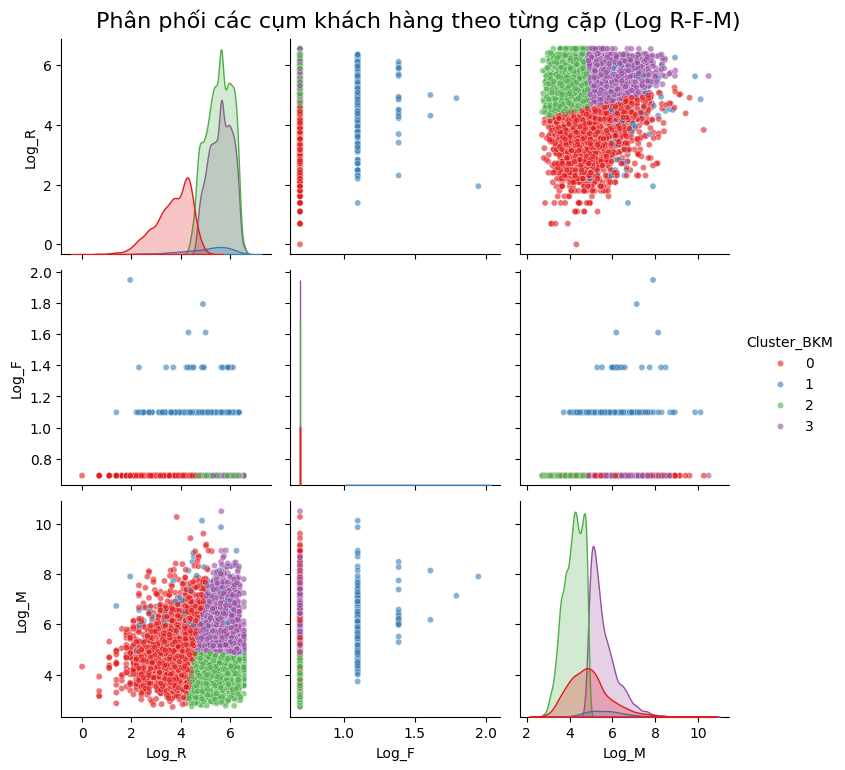

3. Đang vẽ biểu đồ 2D PCA Projection...


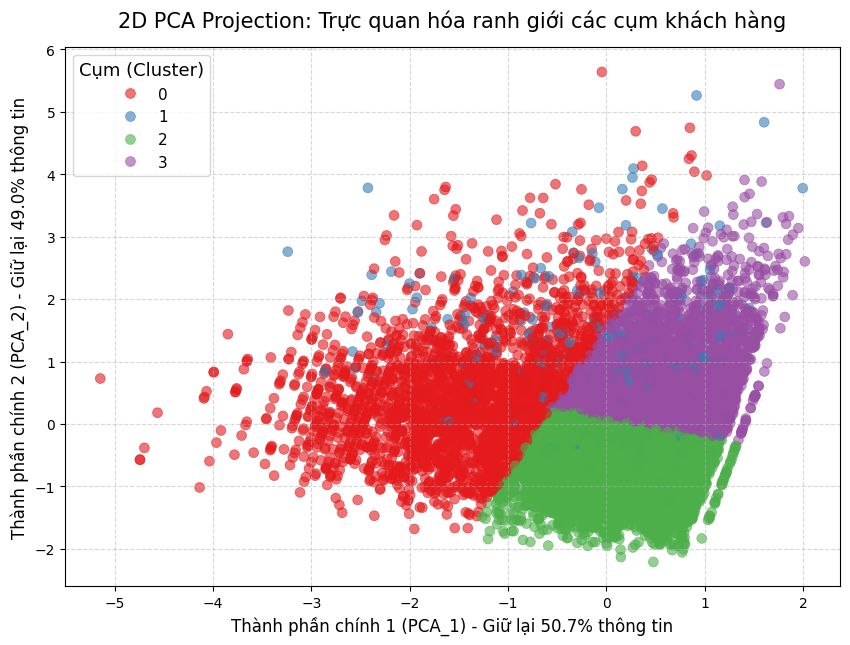

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

print("1. Đang lấy mẫu (sample) 15% dữ liệu để tránh tràn RAM...")
# Lấy ngẫu nhiên 15% dữ liệu để vẽ biểu đồ cho nhẹ và nhanh
# Đổi "df_bkm_result" thành "df_kmeans_result" nếu bạn muốn vẽ cho mô hình K-Means
df_plot_spark = df_bkm_result.sample(fraction=0.15, seed=42)

# Chuyển sang Pandas DataFrame
df_plot = df_plot_spark.select("Recency", "Frequency", "Monetary", "Cluster_BKM").toPandas()

# ==========================================================
# 📈 BIỂU ĐỒ 1: RFM PAIRS (Phân phối chéo giữa R, F, M)
# ==========================================================
print("2. Đang vẽ biểu đồ RFM Pairs...")
# Sử dụng Log transform tạm thời cho trục tọa độ để hình đỡ bị bẹp do outliers
df_plot['Log_R'] = np.log1p(df_plot['Recency'])
df_plot['Log_F'] = np.log1p(df_plot['Frequency'])
df_plot['Log_M'] = np.log1p(df_plot['Monetary'])

plt.figure(figsize=(12, 10))
# Vẽ Pairplot trên dữ liệu Log để thấy rõ các cụm
pair_plot = sns.pairplot(
    df_plot,
    vars=["Log_R", "Log_F", "Log_M"],
    hue="Cluster_BKM",
    palette="Set1",
    diag_kind="kde",
    plot_kws={'alpha': 0.6, 's': 20}
)
pair_plot.fig.suptitle("Phân phối các cụm khách hàng theo từng cặp (Log R-F-M)", y=1.02, fontsize=16)
plt.show()

# ==========================================================
# 📉 BIỂU ĐỒ 2: 2D PCA PROJECTION (Nén 3 chiều R,F,M xuống 2 chiều)
# ==========================================================
print("3. Đang vẽ biểu đồ 2D PCA Projection...")
# Khởi tạo thuật toán PCA giảm xuống 2 chiều
pca = PCA(n_components=2)

# Thực hiện giảm chiều trên 3 biến Log_R, Log_F, Log_M
pca_features = pca.fit_transform(df_plot[['Log_R', 'Log_F', 'Log_M']])

# Gắn kết quả PCA vào DataFrame
df_plot['PCA_1'] = pca_features[:, 0]
df_plot['PCA_2'] = pca_features[:, 1]

# Tính tỷ lệ phương sai (variance) mà 2 trục PCA giữ lại được
var_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_plot,
    x='PCA_1',
    y='PCA_2',
    hue='Cluster_BKM',
    palette='Set1',
    alpha=0.6,
    s=50,
    edgecolor=None
)

plt.title("2D PCA Projection: Trực quan hóa ranh giới các cụm khách hàng", fontsize=15, pad=15)
plt.xlabel(f"Thành phần chính 1 (PCA_1) - Giữ lại {var_ratio[0]*100:.1f}% thông tin", fontsize=12)
plt.ylabel(f"Thành phần chính 2 (PCA_2) - Giữ lại {var_ratio[1]*100:.1f}% thông tin", fontsize=12)
plt.legend(title="Cụm (Cluster)", title_fontsize='13', fontsize='11', loc='best')
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# GMM

⏳ Đang chạy vòng lặp khảo sát K cho Gaussian Mixture (2-10)...
K = 2 | Log-Likelihood = -187209.14 | Silhouette = 0.9092
K = 3 | Log-Likelihood = -99673.72 | Silhouette = 0.8943
K = 4 | Log-Likelihood = -86095.16 | Silhouette = 0.8537
K = 5 | Log-Likelihood = 593767.96 | Silhouette = 0.8024
K = 6 | Log-Likelihood = 437065.76 | Silhouette = 0.7525
K = 7 | Log-Likelihood = 661262.22 | Silhouette = 0.7515
K = 8 | Log-Likelihood = 781282.39 | Silhouette = 0.7998
K = 9 | Log-Likelihood = 587880.07 | Silhouette = 0.7836
K = 10 | Log-Likelihood = 795718.41 | Silhouette = 0.7822


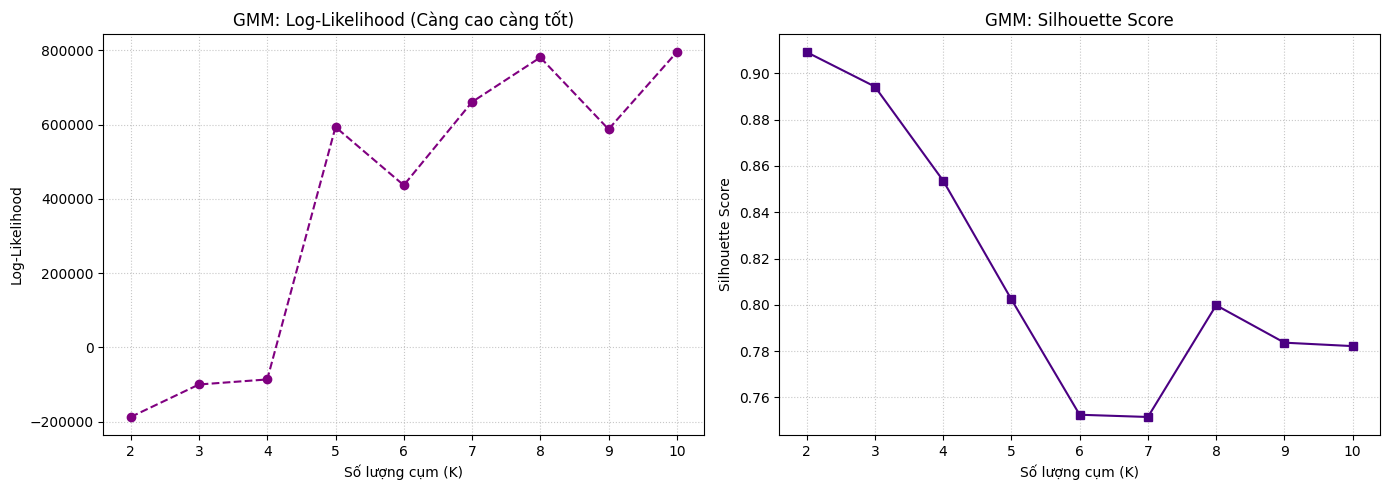

In [ ]:
from pyspark.ml.clustering import GaussianMixture
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt

# 1. Khởi tạo danh sách lưu kết quả
k_values = list(range(2, 11))
gmm_log_likelihood = []
gmm_silhouette_scores = []

# Khởi tạo công cụ đánh giá Silhouette
evaluator = ClusteringEvaluator(
    predictionCol="prediction",
    featuresCol="features",
    metricName="silhouette"
)

print("⏳ Đang chạy vòng lặp khảo sát K cho Gaussian Mixture (2-10)...")

for k in k_values:
    # 2. Khai báo mô hình GMM với các tham số yêu cầu (tol, maxIter)
    gmm = GaussianMixture(
        featuresCol="features",
        k=k,
        seed=42,
        tol=0.01,    # Ngưỡng hội tụ theo yêu cầu
        maxIter=100  # Số vòng lặp tối đa theo yêu cầu
    )

    model = gmm.fit(df_rfm_final)

    # 3. Lấy Log-Likelihood (Thay thế cho WSSSE trong GMM)
    log_likelihood = model.summary.logLikelihood
    gmm_log_likelihood.append(log_likelihood)

    # 4. Tính Silhouette Score
    predictions = model.transform(df_rfm_final)
    silhouette = evaluator.evaluate(predictions)
    gmm_silhouette_scores.append(silhouette)

    print(f"K = {k} | Log-Likelihood = {log_likelihood:.2f} | Silhouette = {silhouette:.4f}")

# ==========================================
# VẼ BIỂU ĐỒ KHẢO SÁT CHO GMM
# ==========================================
plt.figure(figsize=(14, 5))

# Biểu đồ 1: Log-Likelihood (Thay cho Elbow)
# Lưu ý: Log-Likelihood thường tăng khi K tăng
plt.subplot(1, 2, 1)
plt.plot(k_values, gmm_log_likelihood, marker='o', linestyle='--', color='purple')
plt.title('GMM: Log-Likelihood (Càng cao càng tốt)')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('Log-Likelihood')
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.7)

# Biểu đồ 2: Silhouette cho GMM
plt.subplot(1, 2, 2)
plt.plot(k_values, gmm_silhouette_scores, marker='s', linestyle='-', color='indigo')
plt.title('GMM: Silhouette Score')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
from pyspark.ml.clustering import GaussianMixture
from pyspark.ml.evaluation import ClusteringEvaluator
import pyspark.sql.functions as F
from pyspark.sql.types import FloatType
import numpy as np

# ==========================================================
# 2. GAUSSIAN MIXTURE MODEL (GMM) - HUẤN LUYỆN VỚI K=4
# ==========================================================
print("\n==========================================================")
print("2. ĐANG HUẤN LUYỆN VÀ PHÂN TÍCH GMM (K=4)...")
print("==========================================================")

# Khởi tạo mô hình GMM với đầy đủ tham số thầy yêu cầu
gmm = GaussianMixture(
    featuresCol="features",
    k=4,
    seed=42,
    tol=0.01,     # Ngưỡng hội tụ (Tolerance)
    maxIter=100   # Số vòng lặp tối đa
)
gmm_model = gmm.fit(df_rfm_final)

# Phân cụm khách hàng
df_gmm_result = gmm_model.transform(df_rfm_final).withColumnRenamed("prediction", "Cluster_GMM")

# Đánh giá Silhouette Score
evaluator = ClusteringEvaluator(featuresCol="features", metricName="silhouette", predictionCol="Cluster_GMM")
silhouette_gmm = evaluator.evaluate(df_gmm_result)

# --- TÍNH TOÁN WSSSE THỦ CÔNG CHO GMM ---
# Lấy danh sách các tâm (means) của 4 Gaussian
gaussians_list = gmm_model.gaussiansDF.select("mean").collect()
gmm_centers = [row["mean"].toArray() for row in gaussians_list]

# Định nghĩa hàm tính bình phương khoảng cách
def calc_squared_error(features, cluster_id):
    point = features.toArray()
    center = gmm_centers[int(cluster_id)] # Đảm bảo cluster_id là số nguyên
    return float(np.sum((point - center) ** 2))

se_udf = F.udf(calc_squared_error, FloatType())

# Tính tổng WSSSE
df_gmm_se = df_gmm_result.withColumn("Squared_Error", se_udf(F.col("features"), F.col("Cluster_GMM")))
wssse_gmm = df_gmm_se.select(F.sum("Squared_Error")).collect()[0][0]

print(f"[KẾT QUẢ GMM]")
print(f"- K được chọn: 4")
print(f"- Silhouette Score: {silhouette_gmm:.4f}")
print(f"- Within-Set SSE (WSSSE): {wssse_gmm:,.0f}")
print(f"- Log-Likelihood: {gmm_model.summary.logLikelihood:.2f}\n")

# ==========================================================
# THỐNG KÊ ĐẶC ĐIỂM CỤM (PROFILING)
# ==========================================================
print("--- ĐẶC ĐIỂM CÁC CỤM KHÁCH HÀNG (GMM K=4) ---")
cluster_summary_gmm = (df_gmm_result
    .groupBy("Cluster_GMM")
    .agg(
        F.count("customer_unique_id").alias("Số_Lượng_KH"),
        F.round(F.mean("Recency"), 1).alias("Trung_bình_Recency"),
        F.round(F.mean("Frequency"), 2).alias("Trung_bình_Frequency"),
        F.round(F.mean("Monetary"), 2).alias("Trung_bình_Monetary")
    )
    .orderBy("Cluster_GMM")
)

cluster_summary_gmm.show()


2. ĐANG HUẤN LUYỆN VÀ PHÂN TÍCH GMM (K=4)...
[KẾT QUẢ GMM]
- K được chọn: 4
- Silhouette Score: 0.8537
- Within-Set SSE (WSSSE): 187,025
- Log-Likelihood: -86095.16

--- ĐẶC ĐIỂM CÁC CỤM KHÁCH HÀNG (GMM K=4) ---
+-----------+-----------+------------------+--------------------+-------------------+
|Cluster_GMM|Số_Lượng_KH|Trung_bình_Recency|Trung_bình_Frequency|Trung_bình_Monetary|
+-----------+-----------+------------------+--------------------+-------------------+
|          0|         51|               0.9|                1.18|              185.5|
|          1|        189|             180.7|                3.44|             946.43|
|          2|       2264|             210.5|                 2.0|             424.61|
|          3|      91930|             239.3|                 1.0|              205.0|
+-----------+-----------+------------------+--------------------+-------------------+



1. Đang lấy mẫu (sample) 15% dữ liệu GMM để trực quan hóa...
2. Đang vẽ biểu đồ RFM Pairs cho GMM...


<Figure size 1200x1000 with 0 Axes>

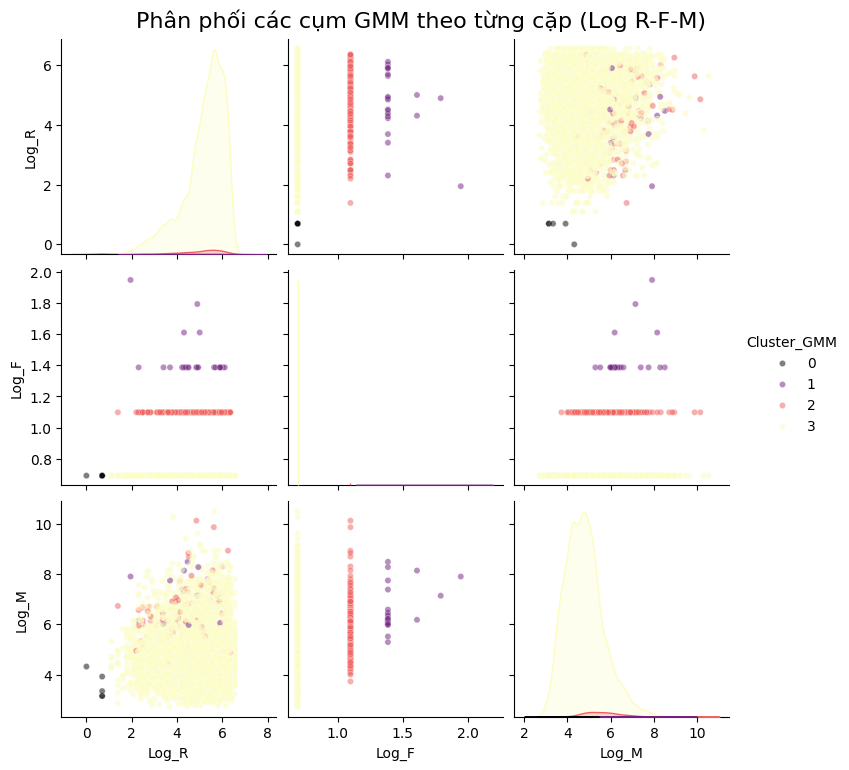

3. Đang vẽ biểu đồ 2D PCA Projection cho GMM...


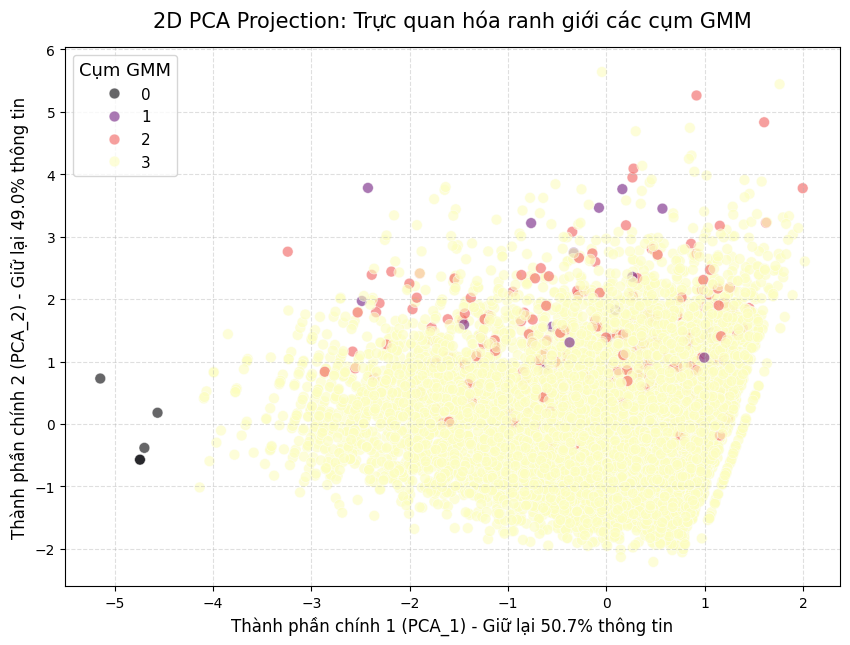

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

print("1. Đang lấy mẫu (sample) 15% dữ liệu GMM để trực quan hóa...")
# Lấy mẫu từ kết quả của mô hình GMM
df_plot_spark = df_gmm_result.sample(fraction=0.15, seed=42)

# Chuyển sang Pandas DataFrame và chọn cột nhãn của GMM
df_plot = df_plot_spark.select("Recency", "Frequency", "Monetary", "Cluster_GMM").toPandas()

# Chuẩn bị dữ liệu Log để biểu đồ đẹp hơn (tránh lệch do outliers)
df_plot['Log_R'] = np.log1p(df_plot['Recency'])
df_plot['Log_F'] = np.log1p(df_plot['Frequency'])
df_plot['Log_M'] = np.log1p(df_plot['Monetary'])

# ==========================================================
# 📈 BIỂU ĐỒ 1: RFM PAIRS (Dành cho GMM)
# ==========================================================
print("2. Đang vẽ biểu đồ RFM Pairs cho GMM...")
plt.figure(figsize=(12, 10))
pair_plot = sns.pairplot(
    df_plot,
    vars=["Log_R", "Log_F", "Log_M"],
    hue="Cluster_GMM",
    palette="magma", # Sử dụng màu magma để phân biệt với các mô hình trước
    diag_kind="kde",
    plot_kws={'alpha': 0.5, 's': 20}
)
pair_plot.fig.suptitle("Phân phối các cụm GMM theo từng cặp (Log R-F-M)", y=1.02, fontsize=16)
plt.show()

# ==========================================================
# 📉 BIỂU ĐỒ 2: 2D PCA PROJECTION (Dành cho GMM)
# ==========================================================
print("3. Đang vẽ biểu đồ 2D PCA Projection cho GMM...")
pca = PCA(n_components=2)
pca_features = pca.fit_transform(df_plot[['Log_R', 'Log_F', 'Log_M']])

df_plot['PCA_1'] = pca_features[:, 0]
df_plot['PCA_2'] = pca_features[:, 1]
var_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_plot,
    x='PCA_1',
    y='PCA_2',
    hue='Cluster_GMM',
    palette='magma',
    alpha=0.6,
    s=60,
    edgecolor='w', # Thêm viền trắng nhẹ để thấy độ chồng lấn (đặc trưng của GMM)
    linewidth=0.5
)

plt.title("2D PCA Projection: Trực quan hóa ranh giới các cụm GMM", fontsize=15, pad=15)
plt.xlabel(f"Thành phần chính 1 (PCA_1) - Giữ lại {var_ratio[0]*100:.1f}% thông tin", fontsize=12)
plt.ylabel(f"Thành phần chính 2 (PCA_2) - Giữ lại {var_ratio[1]*100:.1f}% thông tin", fontsize=12)
plt.legend(title="Cụm GMM", title_fontsize='13', fontsize='11', loc='best')
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [ ]:
# =====================================================================
# PHẦN CUỐI: ĐÓNG GÓI END-TO-END PIPELINE & LƯU LÊN DRIVE CHO GRADIO
# =====================================================================
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans, BisectingKMeans, GaussianMixture
from pyspark.ml import Pipeline, PipelineModel

print("1. Khởi tạo các công cụ biến đổi dữ liệu (Transformer)...")
rfm_assembler = VectorAssembler(
    inputCols=["Log_R", "Log_F", "Log_M"],
    outputCol="unscaled_features"
)

rfm_scaler = StandardScaler(
    inputCol="unscaled_features",
    outputCol="features",
    withStd=True,
    withMean=True
)

print("2. Khởi tạo 3 mô hình thuật toán (Estimator) với K=4...")
kmeans = KMeans(featuresCol="features", predictionCol="Cluster_KMeans", k=4, seed=42, initMode="k-means||", initSteps=2, tol=1e-4)
bkmeans = BisectingKMeans(featuresCol="features", predictionCol="Cluster_BKM", k=4, seed=42, minDivisibleClusterSize=1.0)
gmm = GaussianMixture(featuresCol="features", predictionCol="Cluster_GMM", k=4, seed=42, tol=0.01, maxIter=100)

print("3. Tạo và Huấn luyện Base Pipeline (Tiền xử lý)...")
base_rfm_pipeline = Pipeline(stages=[rfm_assembler, rfm_scaler])
base_rfm_model = base_rfm_pipeline.fit(df_rfm_log)

# Biến đổi dữ liệu qua Base Pipeline
df_rfm_scaled = base_rfm_model.transform(df_rfm_log)

print("4. Huấn luyện 3 mô hình Clustering trên dữ liệu đã chuẩn hóa...")
kmeans_model = kmeans.fit(df_rfm_scaled)
bkm_model = bkmeans.fit(df_rfm_scaled)
gmm_model = gmm.fit(df_rfm_scaled)

print("5. Đóng gói thành End-to-End Pipelines...")
# Gắn liền Base Pipeline và Mô hình đã train thành một khối đồng nhất
final_kmeans_pipeline = PipelineModel(stages=[base_rfm_model, kmeans_model])
final_bkmeans_pipeline = PipelineModel(stages=[base_rfm_model, bkm_model])
final_gmm_pipeline = PipelineModel(stages=[base_rfm_model, gmm_model])

print("\n================ 6. LƯU END-TO-END PIPELINES CHO GRADIO ================")
base_drive_path = "/content/gdrive/MyDrive/BIGDATA/"

kmeans_save_path = base_drive_path + "gradio_rfm_kmeans_pipeline"
bkmeans_save_path = base_drive_path + "gradio_rfm_bkmeans_pipeline"
gmm_save_path = base_drive_path + "gradio_rfm_gmm_pipeline"

# Lưu đè lên Drive
final_kmeans_pipeline.write().overwrite().save(kmeans_save_path)
final_bkmeans_pipeline.write().overwrite().save(bkmeans_save_path)
final_gmm_pipeline.write().overwrite().save(gmm_save_path)

print(f"✅ Đã lưu K-Means Pipeline tại: {kmeans_save_path}")
print(f"✅ Đã lưu Bisecting K-Means Pipeline tại: {bkmeans_save_path}")
print(f"✅ Đã lưu GMM Pipeline tại: {gmm_save_path}")
print("🎯 Hệ thống Phân cụm Khách hàng (Clustering) đã sẵn sàng lên Web UI!")

1. Khởi tạo các công cụ biến đổi dữ liệu (Transformer)...
2. Khởi tạo 3 mô hình thuật toán (Estimator) với K=4...
3. Tạo và Huấn luyện Base Pipeline (Tiền xử lý)...
4. Huấn luyện 3 mô hình Clustering trên dữ liệu đã chuẩn hóa...
5. Đóng gói thành End-to-End Pipelines...

================ 6. LƯU END-TO-END PIPELINES CHO GRADIO ================
✅ Đã lưu K-Means Pipeline tại: /content/gdrive/MyDrive/BIGDATA/gradio_rfm_kmeans_pipeline
✅ Đã lưu Bisecting K-Means Pipeline tại: /content/gdrive/MyDrive/BIGDATA/gradio_rfm_bkmeans_pipeline
✅ Đã lưu GMM Pipeline tại: /content/gdrive/MyDrive/BIGDATA/gradio_rfm_gmm_pipeline
🎯 Hệ thống Phân cụm Khách hàng (Clustering) đã sẵn sàng lên Web UI!


In [ ]:
# Giả sử 'kmeans_predictions' là biến DataFrame của Spark chứa kết quả sau khi transform
# (nếu biến của bạn tên khác, ví dụ 'df_predictions', hãy đổi lại cho đúng nhé)

print("\n================ 7. LƯU BẢNG KẾT QUẢ ĐỂ VẼ BIỂU ĐỒ =====================")
# Chọn các cột cần thiết cho biểu đồ 3D và chuyển sang Pandas
df_plot = kmeans_predictions.select("Recency", "Frequency", "Monetary", "prediction").toPandas()

# Lưu thành file CSV trên Drive
csv_save_path = base_drive_path + "clustered_customers_for_plot.csv"
df_plot.to_csv(csv_save_path, index=False)

print(f"✅ Đã lưu Data vẽ biểu đồ tại: {csv_save_path}")